## 15.773 Hands-on Deep Learning - Spring 2026
### Assignment 1 - Roman Burdakov

## SETUP

Execute the code cells below and then proceed to the instructions.

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [ ]:
!pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.2 MB/s eta 0:00:00


In [ ]:
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras_tuner as kt

Download the data:

In [ ]:
(x_train, y_train), (x_val, y_val) = keras.datasets.california_housing.load_data(
    version="large", path="california_housing.npz", test_split=0.2, seed=113
)

743530/743530 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


Scale down the y values to make the MSE numbers less annoying to look at.

In [ ]:
y_train = y_train/1000.0
y_val = y_val/1000.0

## INSTRUCTIONS

### Dataset

Edited from https://keras.io/api/datasets/california_housing/

You have downloaded the (famous?) California Housing dataset. This dataset was derived from the 1990 U.S. census.

Each row of the data is for a **block group**. A block group is the smallest geographical unit for which the U.S. Census Bureau publishes sample data and typically has a population of 600-3,000 people.

This is a regression dataset with 8 features (i.e., **independent** variables). The target variable (i.e., the **dependent** variable) is the median house value in block group, in thousands of dollars.

The 8 input features are the following:

* Latitude: block group latitude
* Longitude: block group longitude
* HouseAge: median house age in block group
* TotRooms: Total number of rooms per household in block group
* TotBedrms: Total number of bedrooms per household in block group
* Population: Population of block group
* TotOccup: Total number of households in block group
* MedInc: median income in block group

(the order of the input features does not matter for this problem)



The 20,640 rows of data have been split into train and validation sets and stored in numpy arrays.
* `x_train`, `x_val`: numpy arrays containing the training and validation X matrices, respectively.

* `y_train`, `y_val`: numpy arrays containing the values of the dependent variable for the training and validation sets respectively. These are numbers typically between 25 and 500 and represent home prices in thousands of dollars.

### Assignment

To answer the questions below, feel free to use/re-use the code in the [Neural Heart Disease Prediction Model colab](https://colab.research.google.com/drive/1TC9qGjGaCdp68BIiGWQDgIKAa1a6J57y?usp=drive_link) that we covered in class.

First, standardize `x_train` and `x_val` using the mean and standard deviation of `x_train`. Then complete the following four parts.

Part I
* Set the random seed: `keras.utils.set_random_seed(42)`
* Define a Keras model with a single hidden layer of 16 neurons
* Use `model.compile` with `adam` as the optimizer and `mse` as the loss
* Train the Keras model for 100 epochs with `model.fit`, using a batch size of 32.
* Plot loss curves for the training and validation sets.
* From the loss curves, do you see any evidence of overfitting? Comment briefly.
* Evaluate the model on the validation set and report the MSE.


Part II
* Set the random seed: `keras.utils.set_random_seed(42)`
* Take the Keras model you defined in Part I and add another hidden layer of 16 neurons. Then repeat the steps from Part I.

Part III
* Set the random seed: `keras.utils.set_random_seed(42)`
* Take the Keras model you defined in Part I. Modify it so that the input layer is connected directly to the output layer as well (i.e., the input layer should be connected to the hidden layer **AND** the output layer). Then repeat the steps from Part I.

Hint: Use `keras.layers.Concatenate`

Part IV
* Set the random seed: `keras.utils.set_random_seed(42)`

Using Keras Tuner, do hyperparameter optimization across:
- the number of layers: [1,2,3]
- the number of units in each layer: [4, 8, 16]

(i.e., 9 hyper-parameter combinations)

For this part, the input layer should be connected only to the first hidden layer like we normally do (**NOT** like what we asked you to do in Part III).


Answer these questions in text cells:
* What is the optimal hyper-parameter combination?
* What is the MSE of the optimal model?
* How does this optimal model's MSE compare to the MSE of the models found in Parts I, II and III?

**COMPLETE ALL THE ABOVE BY ADDING CODE AND TEXT CELLS TO THIS NOTEBOOK BELOW THIS CELL.**

In [ ]:
x_train[:1]

array([[-118.27  ,   34.09  ,   52.    , 2327.    ,  555.    , 1048.    ,
         491.    ,    3.7847]], dtype=float32)

In [ ]:
# standardize x_train, x_val
means = x_train.mean(axis=0)
sd = x_train.std(axis=0)
x_train = (x_train - means)/sd
x_val = (x_val - means)/sd

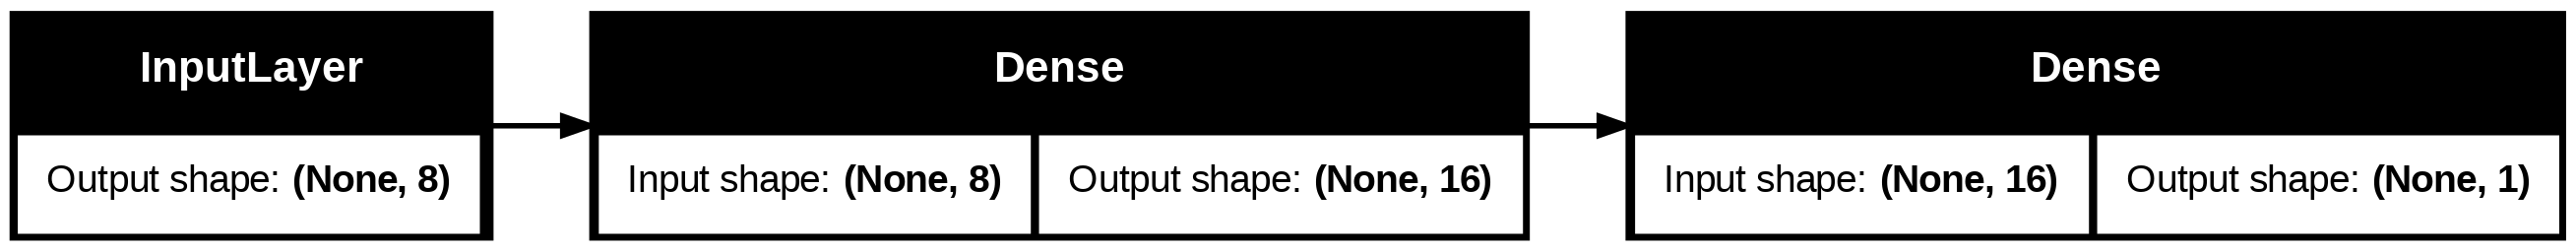

In [ ]:
keras.utils.set_random_seed(42)

# define the input layer
input = keras.layers.Input(shape=x_train.shape[1:])
# feed the input vector to the hidden layer
h = keras.layers.Dense(16, activation="relu", name="Hidden")(input)
# feed the output of the hidden layer to the output layer
output = keras.layers.Dense(1, name="Output")(h)
# tell Keras that this (input,output) pair is your model
model = keras.Model(input, output)

keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

In [ ]:
model.compile(optimizer="adam",
              loss="mse",
              metrics=["mae",
                       keras.metrics.RootMeanSquaredError(name="rmse")])

history = model.fit(x_train,              # the array with the input X columns
                    y_train,              # the array with the output y column
                    epochs=100,           # number of epochs to run
                    batch_size=32,        # number of samples (ie data points) per batch
                    verbose=1,            # verbosity during training
                    validation_data=(x_val, y_val)) # validation data

Epoch 1/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 53927.9883 - mae: 202.5875 - rmse: 232.2202 - val_loss: 49814.5469 - val_mae: 192.8390 - val_rmse: 223.1917
Epoch 2/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45726.5977 - mae: 183.2909 - rmse: 213.8154 - val_loss: 37006.9766 - val_mae: 160.5357 - val_rmse: 192.3720
Epoch 3/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 32961.5781 - mae: 149.5828 - rmse: 181.5074 - val_loss: 24517.5098 - val_mae: 123.4155 - val_rmse: 156.5807
Epoch 4/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21725.4492 - mae: 114.0592 - rmse: 147.3509 - val_loss: 16054.7705 - val_mae: 94.6861 - val_rmse: 126.7074
Epoch 5/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14664.2686 - mae: 89.5737 - rmse: 121.0786 - val_loss: 11857.2842 - val_mae: 80.8779 - val_rmse: 108.8912
Epoch 6/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11273.4463 - mae: 78.2417 - rmse: 106.1700 - val_loss: 9936.7588 - val_mae: 74.1626 - val_rmse: 9

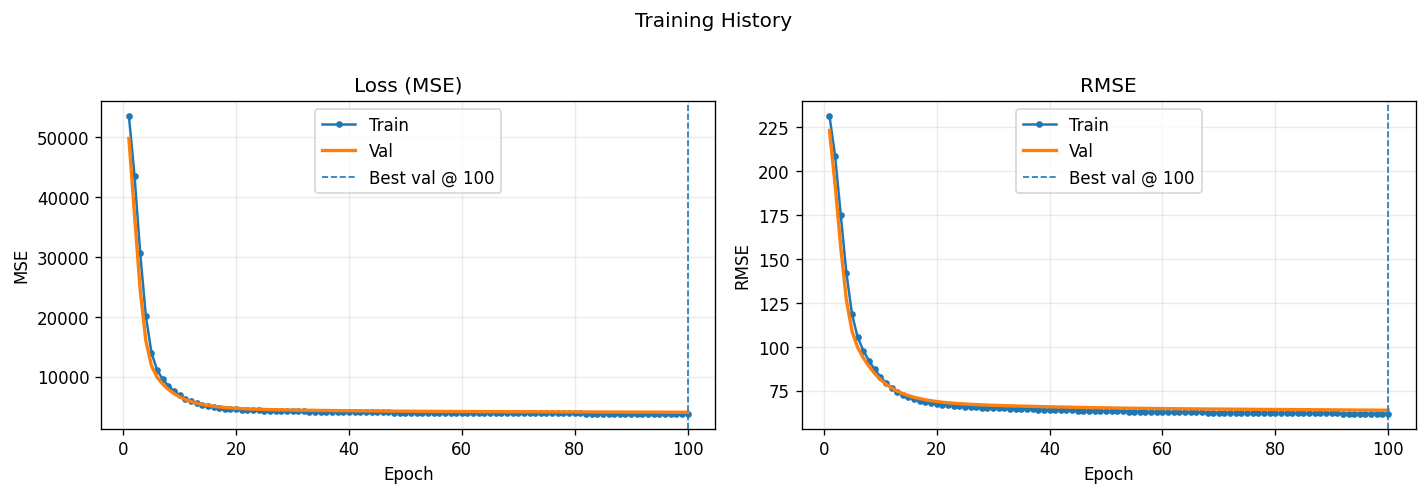

Val MSE : 4091.310547
Val MAE : 45.686882
Val RMSE: 63.963352


In [ ]:
def plot_history(history, metric="rmse"):
    h = history.history
    epochs = np.arange(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=120)

    # --- Left: Loss (MSE) ---
    ax = axes[0]
    ax.plot(epochs, h["loss"], marker="o", markersize=3, linewidth=1.5, label="Train")
    ax.plot(epochs, h["val_loss"], linewidth=2, label="Val")
    best_epoch = int(np.argmin(h["val_loss"]) + 1)
    ax.axvline(best_epoch, linestyle="--", linewidth=1, label=f"Best val @ {best_epoch}")

    ax.set_title("Loss (MSE)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.grid(True, alpha=0.25)
    ax.legend()

    # --- Right: Metric (RMSE by default) ---
    ax = axes[1]
    ax.plot(epochs, h[metric], marker="o", markersize=3, linewidth=1.5, label="Train")
    ax.plot(epochs, h[f"val_{metric}"], linewidth=2, label="Val")
    ax.axvline(best_epoch, linestyle="--", linewidth=1, label=f"Best val @ {best_epoch}")

    ax.set_title(f"{metric.upper()}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.upper())
    ax.grid(True, alpha=0.25)
    ax.legend()

    fig.suptitle("Training History", y=1.02)
    fig.tight_layout()
    plt.show()

def print_metrics(model):
  res = model.evaluate(x_val, y_val, verbose=0, return_dict=True)
  print(f"Val MSE : {res['loss']:.6f}")
  print(f"Val MAE : {res['mae']:.6f}")
  print(f"Val RMSE: {res['rmse']:.6f}")

plot_history(history)
print_metrics(model)

Based on the loss plot, there is **no strong evidance of overfitting**. Validation loss does not trend upward; at most it plateaus while training loss continues to decrease, suggesting diminishing returns rather than clear overfitting

In [ ]:
keras.utils.set_random_seed(42)

input2 = keras.layers.Input(shape=x_train.shape[1:])
h1 = keras.layers.Dense(16, activation="relu", name="Hidden_1")(input2)
h2 = keras.layers.Dense(16, activation="relu", name="Hidden_2")(h1)
output2 = keras.layers.Dense(1, name="Output")(h2)

# tell Keras that this (input,output) pair is your model
model2 = keras.Model(input2, output2)

model2.compile(optimizer="adam",
              loss="mse",
              metrics=["mae",
                       keras.metrics.RootMeanSquaredError(name="rmse")])

history2 = model2.fit(x_train,              # the array with the input X columns
                    y_train,              # the array with the output y column
                    epochs=100,           # number of epochs to run
                    batch_size=32,        # number of samples (ie data points) per batch
                    verbose=1,            # verbosity during training
                    validation_data=(x_val, y_val)) # validation data

Epoch 1/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 51308.2109 - mae: 195.4847 - rmse: 226.3960 - val_loss: 17499.4180 - val_mae: 98.0149 - val_rmse: 132.2854
Epoch 2/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12864.5723 - mae: 82.7703 - rmse: 113.1812 - val_loss: 7824.3062 - val_mae: 65.2317 - val_rmse: 88.4551
Epoch 3/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7330.6440 - mae: 62.3430 - rmse: 85.6062 - val_loss: 6337.5171 - val_mae: 58.1056 - val_rmse: 79.6085
Epoch 4/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5845.8105 - mae: 55.4674 - rmse: 76.4468 - val_loss: 5464.4995 - val_mae: 54.1132 - val_rmse: 73.9223
Epoch 5/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4993.4727 - mae: 51.2736 - rmse: 70.6512 - val_loss: 4965.0601 - val_mae: 51.5526 - val_rmse: 70.4632
Epoch 6/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4535.5854 - mae: 48.7803 - rmse: 67.3301 - val_loss: 4729.6411 - val_mae: 50.1482 - val_rmse: 68.7724
Epoch 7/100
516

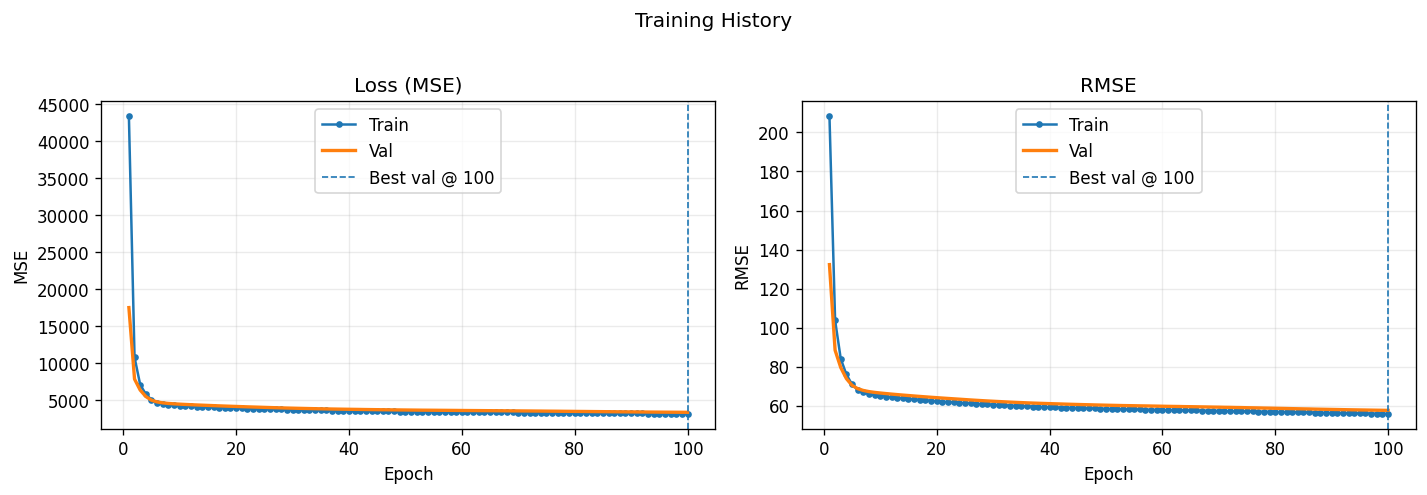

Val MSE : 3324.302002
Val MAE : 40.260414
Val RMSE: 57.656761


In [ ]:
plot_history(history2)
print_metrics(model2)

Training and validation loss decrease together and then plateau, with no sustained rise in validation loss; hence there is still **no clear evidence of overfitting**

In [ ]:
keras.utils.set_random_seed(42)

input3 = keras.layers.Input(shape=x_train.shape[1:])
hidden3 = keras.layers.Dense(16, activation="relu")(input3)

merged = keras.layers.Concatenate()([input3, hidden3])

output3 = keras.layers.Dense(1, name="Output")(merged)
model3 = keras.Model(input3, output3)

model3.compile(optimizer="adam",
              loss="mse",
              metrics=["mae",
                       keras.metrics.RootMeanSquaredError(name="rmse")])

history3 = model3.fit(x_train,              # the array with the input X columns
                      y_train,              # the array with the output y column
                      epochs=100,           # number of epochs to run
                      batch_size=32,        # number of samples (ie data points) per batch
                      verbose=1,            # verbosity during training
                      validation_data=(x_val, y_val)) # validation data

Epoch 1/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 54074.8555 - mae: 202.8018 - rmse: 232.5362 - val_loss: 50097.6367 - val_mae: 193.0395 - val_rmse: 223.8250
Epoch 2/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45962.9023 - mae: 183.2655 - rmse: 214.3666 - val_loss: 36960.5039 - val_mae: 159.7541 - val_rmse: 192.2511
Epoch 3/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 32778.9141 - mae: 148.4039 - rmse: 180.9973 - val_loss: 23681.3340 - val_mae: 120.1502 - val_rmse: 153.8874
Epoch 4/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 20660.3047 - mae: 110.0318 - rmse: 143.6796 - val_loss: 14559.0400 - val_mae: 88.6908 - val_rmse: 120.6609
Epoch 5/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13036.9746 - mae: 83.2591 - rmse: 114.1561 - val_loss: 10342.8613 - val_mae: 74.2549 - val_rmse: 101.6999
Epoch 6/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9740.2812 - mae: 72.1434 - rmse: 98.6838 - val_loss: 8843.2461 - val_mae: 69.1778 - val_rmse: 94.

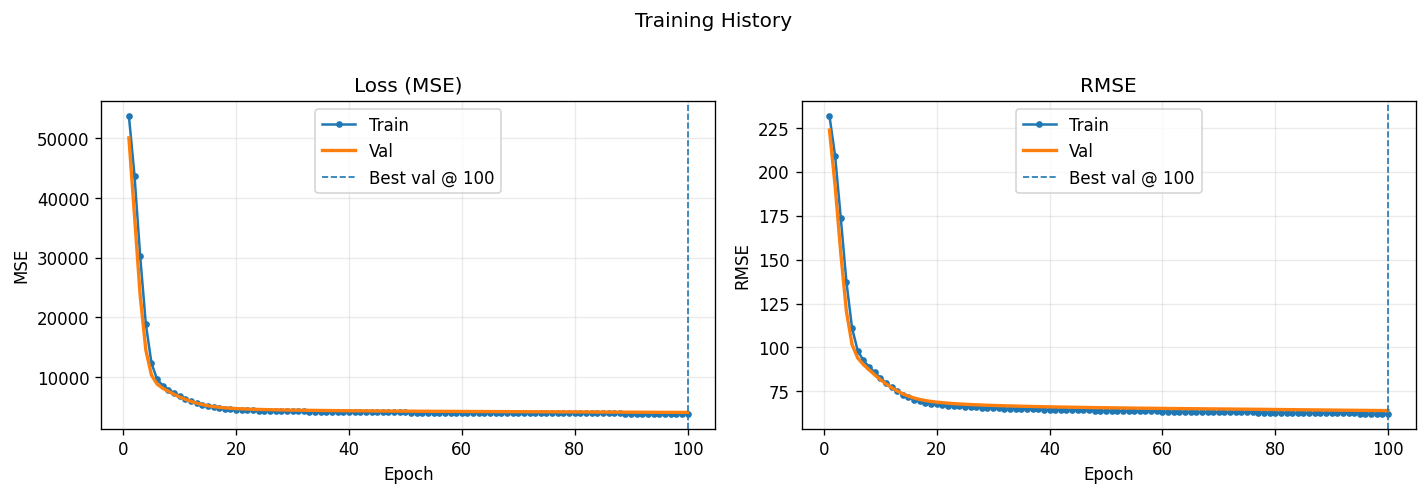

Val MSE : 4100.783691
Val MAE : 45.639225
Val RMSE: 64.037361


In [ ]:
plot_history(history3)
print_metrics(model3)

Validation loss tracks training loss closely and does not trend upward; the curves mostly flatten, indicating **convergence rather than overfitting**

In [ ]:
# 9 hyper-parameter combinations
def build_model(hp):
  input = keras.layers.Input(shape=x_train.shape[1:])
  x = input

  # [1,2,3] hidden layers
  for i in range(hp.Int("num_layers", 1, 3)):
      x = keras.layers.Dense(
          # Vary the number of units
          units=hp.Choice(f"units", [4, 8, 16]),
          activation="relu"
      )(x)

  output = keras.layers.Dense(1, name="Output")(x)
  model = keras.Model(input,output)
  model.compile(optimizer="adam",
                loss="mse",
                metrics=["mae",
                          keras.metrics.RootMeanSquaredError(name="rmse")])

  return model

In [ ]:
keras.utils.set_random_seed(42)

tuner = kt.GridSearch(
    build_model,
    objective="val_loss",
    overwrite=True
)

tuner.search_space_summary()

Search space summary
Default search space size: 2
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
units (Choice)
{'default': 4, 'conditions': [], 'values': [4, 8, 16], 'ordered': True}


In [ ]:
tuner.search(x_train,
             y_train,
             epochs=100,
             batch_size=32,
             verbose=1,
             validation_data=(x_val, y_val))

Trial 9 Complete [00h 01m 36s]
val_loss: 3338.794189453125

Best val_loss So Far: 3338.794189453125
Total elapsed time: 00h 15m 04s


In [ ]:
tuner.results_summary()

Results summary
Results in ./untitled_project
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0008 summary
Hyperparameters:
num_layers: 3
units: 16
Score: 3338.794189453125

Trial 0005 summary
Hyperparameters:
num_layers: 2
units: 16
Score: 3388.197998046875

Trial 0004 summary
Hyperparameters:
num_layers: 2
units: 8
Score: 3802.14404296875

Trial 0007 summary
Hyperparameters:
num_layers: 3
units: 8
Score: 3842.7900390625

Trial 0002 summary
Hyperparameters:
num_layers: 1
units: 16
Score: 4200.115234375

Trial 0001 summary
Hyperparameters:
num_layers: 1
units: 8
Score: 4235.7578125

Trial 0003 summary
Hyperparameters:
num_layers: 2
units: 4
Score: 4312.04296875

Trial 0006 summary
Hyperparameters:
num_layers: 3
units: 4
Score: 4399.24560546875

Trial 0000 summary
Hyperparameters:
num_layers: 1
units: 4
Score: 4584.744140625


In [ ]:
best_model = tuner.get_best_models(1)[0]
best_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

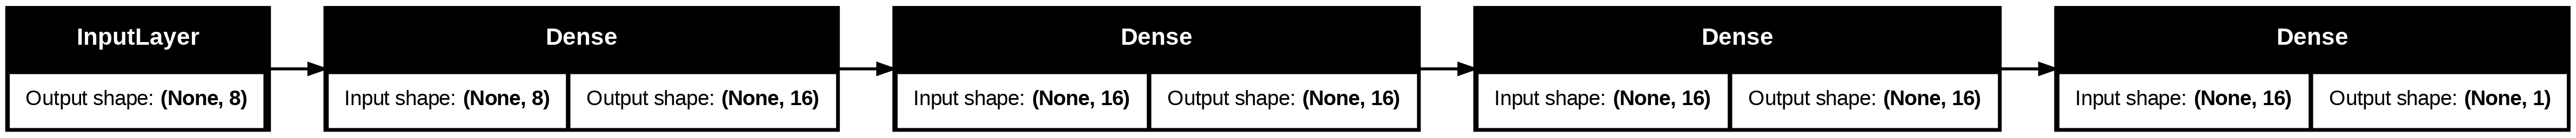

In [ ]:
keras.utils.plot_model(best_model, show_shapes=True, rankdir="LR")

In [ ]:
best_model.evaluate(x_val, y_val, verbose=0)

[3338.794189453125, 40.577049255371094, 57.78229904174805]

* Optimal hyperparameters: 3 hidden layers, 16 units each
* Best validation MSE (val_loss): 3338.794 (in (K$)², since y was divided by 1000)
* Comparison: Best model is ~18.4% better than Part I (4091 → 3339), is ~0.4% worse than Part II (3324 → 3339), and is ~18.6% better than Part III (4101 → 3339).